# DX799 Data Science Capstone — Module C, Milestone Two
**Sean Amisano — Boston University, Faculty of Computing & Data Sciences**

## Datasets

| Dataset | Rows | Used for |
|---|---|---|
| Breast Cancer Wisconsin (Diagnostic) | 569 × 30 | malignancy classification, mean-radius regression |
| UCI Heart Disease (Cleveland) | 303 × 13 | disease classification, cholesterol regression |
| Cancer Data Brazil (RCBP registry) | 1,778,176 × 38 | mortality classification at scale |

Every model in these notebooks is scored on a held-out 25% test split created with a
single fixed random state, and every hyperparameter is chosen by 5-fold cross-validation
on the training portion alone.

---
# Week 10 — K-Means and the silhouette score

K-Means is unsupervised, so "overfitting" in the supervised sense does not apply: there is
no held-out loss to inflate. The analogous failure is choosing k too large. Inertia falls
monotonically in k **by construction**, so it can never identify a best k on its own. The
silhouette score can, because it penalises clusters that are not well separated.

Because breast cancer carries a known diagnosis, this week can ask something supervised
metrics cannot: *does unsupervised geometry rediscover the malignant/benign split without
ever being shown it?*

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
%matplotlib inline
from common import *
print('Random state:', RANDOM_STATE, '| test size:', TEST_SIZE, '| folds:', N_FOLDS)

Random state: 42 | test size: 0.25 | folds: 5


In [2]:
from sklearn.preprocessing import StandardScaler
bc, ht = load_bc(), load_heart()
Xs_b = StandardScaler().fit_transform(bc['X'])
Xs_h = StandardScaler().fit_transform(ht['X'])
y_b, y_h = bc['y_clf'].values, ht['y_clf'].values

## 1. Sweeping k

Four internal indices and two external ones. The external indices (ARI, NMI) are only
available because these datasets happen to carry labels; they are the ground truth against
which the internal indices can be judged.

In [3]:
from week10_kmeans import k_sweep
sweep_b, bestk_b = k_sweep(Xs_b, 'bc', y_b)

[resume] loaded 8 existing keys from week10_kmeans.json

--- bc: k sweep (from saved record) ---
   ARI    NMI  calinski_harabasz  davies_bouldin    inertia  k  silhouette
0.6707 0.5546           267.6964          1.3123 11595.4615  2      0.3450
0.5107 0.4223           197.1140          1.5294 10061.7978  3      0.3144
0.5548 0.4634           158.9416          1.4967  9257.3625  4      0.2803
0.3316 0.4006           140.2511          1.7498  8557.7275  5      0.1585
0.3322 0.4109           128.5566          1.7197  7970.2638  6      0.1604
0.2571 0.3756           118.3787          1.6772  7540.3187  7      0.1532
0.2403 0.3686           110.0688          1.5413  7192.1920  8      0.1392
0.1956 0.3300           104.7536          1.4847  6837.6289  9      0.1470
0.2008 0.3589            98.4480          1.6067  6603.4044 10      0.1367
  best k by silhouette: 2


In [4]:
sweep_h, bestk_h = k_sweep(Xs_h, 'heart', y_h)


--- heart: k sweep (from saved record) ---
   ARI    NMI  calinski_harabasz  davies_bouldin   inertia  k  silhouette
0.3868 0.3234            54.9660          2.1874 3330.7648  2      0.1682
0.2543 0.2749            41.8317          2.3722 3080.0433  3      0.1179
0.1818 0.2009            37.3621          2.1367 2864.9965  4      0.1233
0.1814 0.1959            33.2129          2.0617 2724.4223  5      0.1175
0.1338 0.1668            29.6258          2.1787 2628.1896  6      0.1164
0.1113 0.1696            27.5841          2.2192 2526.3967  7      0.1058
0.1164 0.1881            25.8581          2.0864 2441.1522  8      0.1154
0.1037 0.1757            24.4406          2.0263 2365.6932  9      0.1125
0.0921 0.1799            23.2758          1.9667 2296.8512 10      0.0990
  best k by silhouette: 2


Silhouette peaks at k=2 on breast cancer — the correct answer, recovered without labels.
ARI peaks at k=2 as well, so on this dataset the internal criterion and the external truth
agree. That agreement is not guaranteed, and Week 11 shows it breaking down badly.

## 2. Standardisation, and a warning about silhouette

In [5]:
from week10_kmeans import scaling_matters
scaling_matters(bc['X'], y_b, 'bc')


--- bc: effect of standardisation at k=2 ---
              silhouette  ARI_vs_label  NMI_vs_label
unscaled          0.6973        0.4914        0.4648
standardised      0.3450        0.6707        0.5546


{'unscaled': {'silhouette': 0.6972646156059465,
  'ARI_vs_label': 0.49142453622455523,
  'NMI_vs_label': 0.46479332792160793},
 'standardised': {'silhouette': 0.3449740051034408,
  'ARI_vs_label': 0.6707206476880808,
  'NMI_vs_label': 0.554612218410556}}

**This is the most instructive result of the week.** Unscaled data gives a *higher*
silhouette (0.697 vs 0.345) but a *much lower* ARI (0.465 vs 0.671).

The unscaled clustering is essentially a one-variable split on `worst area`, whose standard
deviation is roughly 570 against 0.003 for `fractal dimension error` — a ratio of about
215,000. A split on a single dominant axis produces tight, well-separated blobs, and
silhouette rewards exactly that. It is measuring geometric tidiness, not clinical meaning.

Silhouette is a useful guide for choosing k *within* a fixed representation. It is not a
tool for choosing between representations.

## 3. Does geometry recover the diagnosis?

In [6]:
from week10_kmeans import agreement_with_label
km_b, lab_b, agree_b = agreement_with_label(Xs_b, y_b, 'bc', k=2)
km_h, lab_h, agree_h = agreement_with_label(Xs_h, y_h, 'heart', k=2)


--- bc: cluster vs true label at k=2 ---
  crosstab (rows = true, cols = cluster):
[[ 14 343]
 [175  37]]
  best-map accuracy 0.9104 | ARI 0.6707 | NMI 0.5546

--- heart: cluster vs true label at k=2 ---
  crosstab (rows = true, cols = cluster):
[[ 93  45]
 [ 12 153]]
  best-map accuracy 0.8119 | ARI 0.3868 | NMI 0.3234


On breast cancer, K-Means with no access to any label assigns 91.0% of patients to the
correct diagnostic group (ARI 0.671). The malignant/benign distinction is not something a
classifier imposes on this data — it is the dominant geometric structure already present
in the measurements.

On heart disease the same procedure reaches 81.2% but ARI only 0.387. The structure exists
but is much weaker, consistent with every supervised result on this dataset.

## 4. The registry, where K-Means struggles

In [7]:
from week10_kmeans import brazil_kmeans
bz = brazil_kmeans()


--- Brazil registry: MiniBatchKMeans on 40,000 rows, 76 encoded dimensions (from saved record) ---
   ARI    NMI     inertia  k  silhouette
0.0796 0.0479 282639.4739  2      0.0999
0.0350 0.0300 261211.2265  3      0.0885
0.0354 0.0326 245151.9269  4      0.0881
0.0499 0.0664 231954.3807  5      0.0932
0.0311 0.0449 226412.4368  6      0.0897
0.0521 0.0634 222492.1476  7      0.0908
0.0382 0.0524 216373.9034  8      0.0870
0.0328 0.0553 210063.2627  9      0.0890
0.0316 0.0551 208987.7665 10      0.0784
  best k by silhouette: 2

Cluster profiles at best k:
 cluster  death_rate  mean_age  mean_year     n top_site
       0       0.546    67.171   2009.811 16039      C44
       1       0.293    58.816   2014.941 23961      C44


Silhouette never exceeds 0.10 at any k, and ARI against mortality peaks around 0.08. After
one-hot encoding, squared Euclidean distance on binary indicators is proportional to the
number of disagreeing category levels, so K-Means degenerates into a crude k-modes. The
centroids it computes are not attainable patients — they are fractional averages of
mutually exclusive categories.

The cluster profiles are still interpretable (one older cohort with 54.6% mortality, one
younger and more recent with 29.3%), but this is a weak result and is reported as one.

## Figure

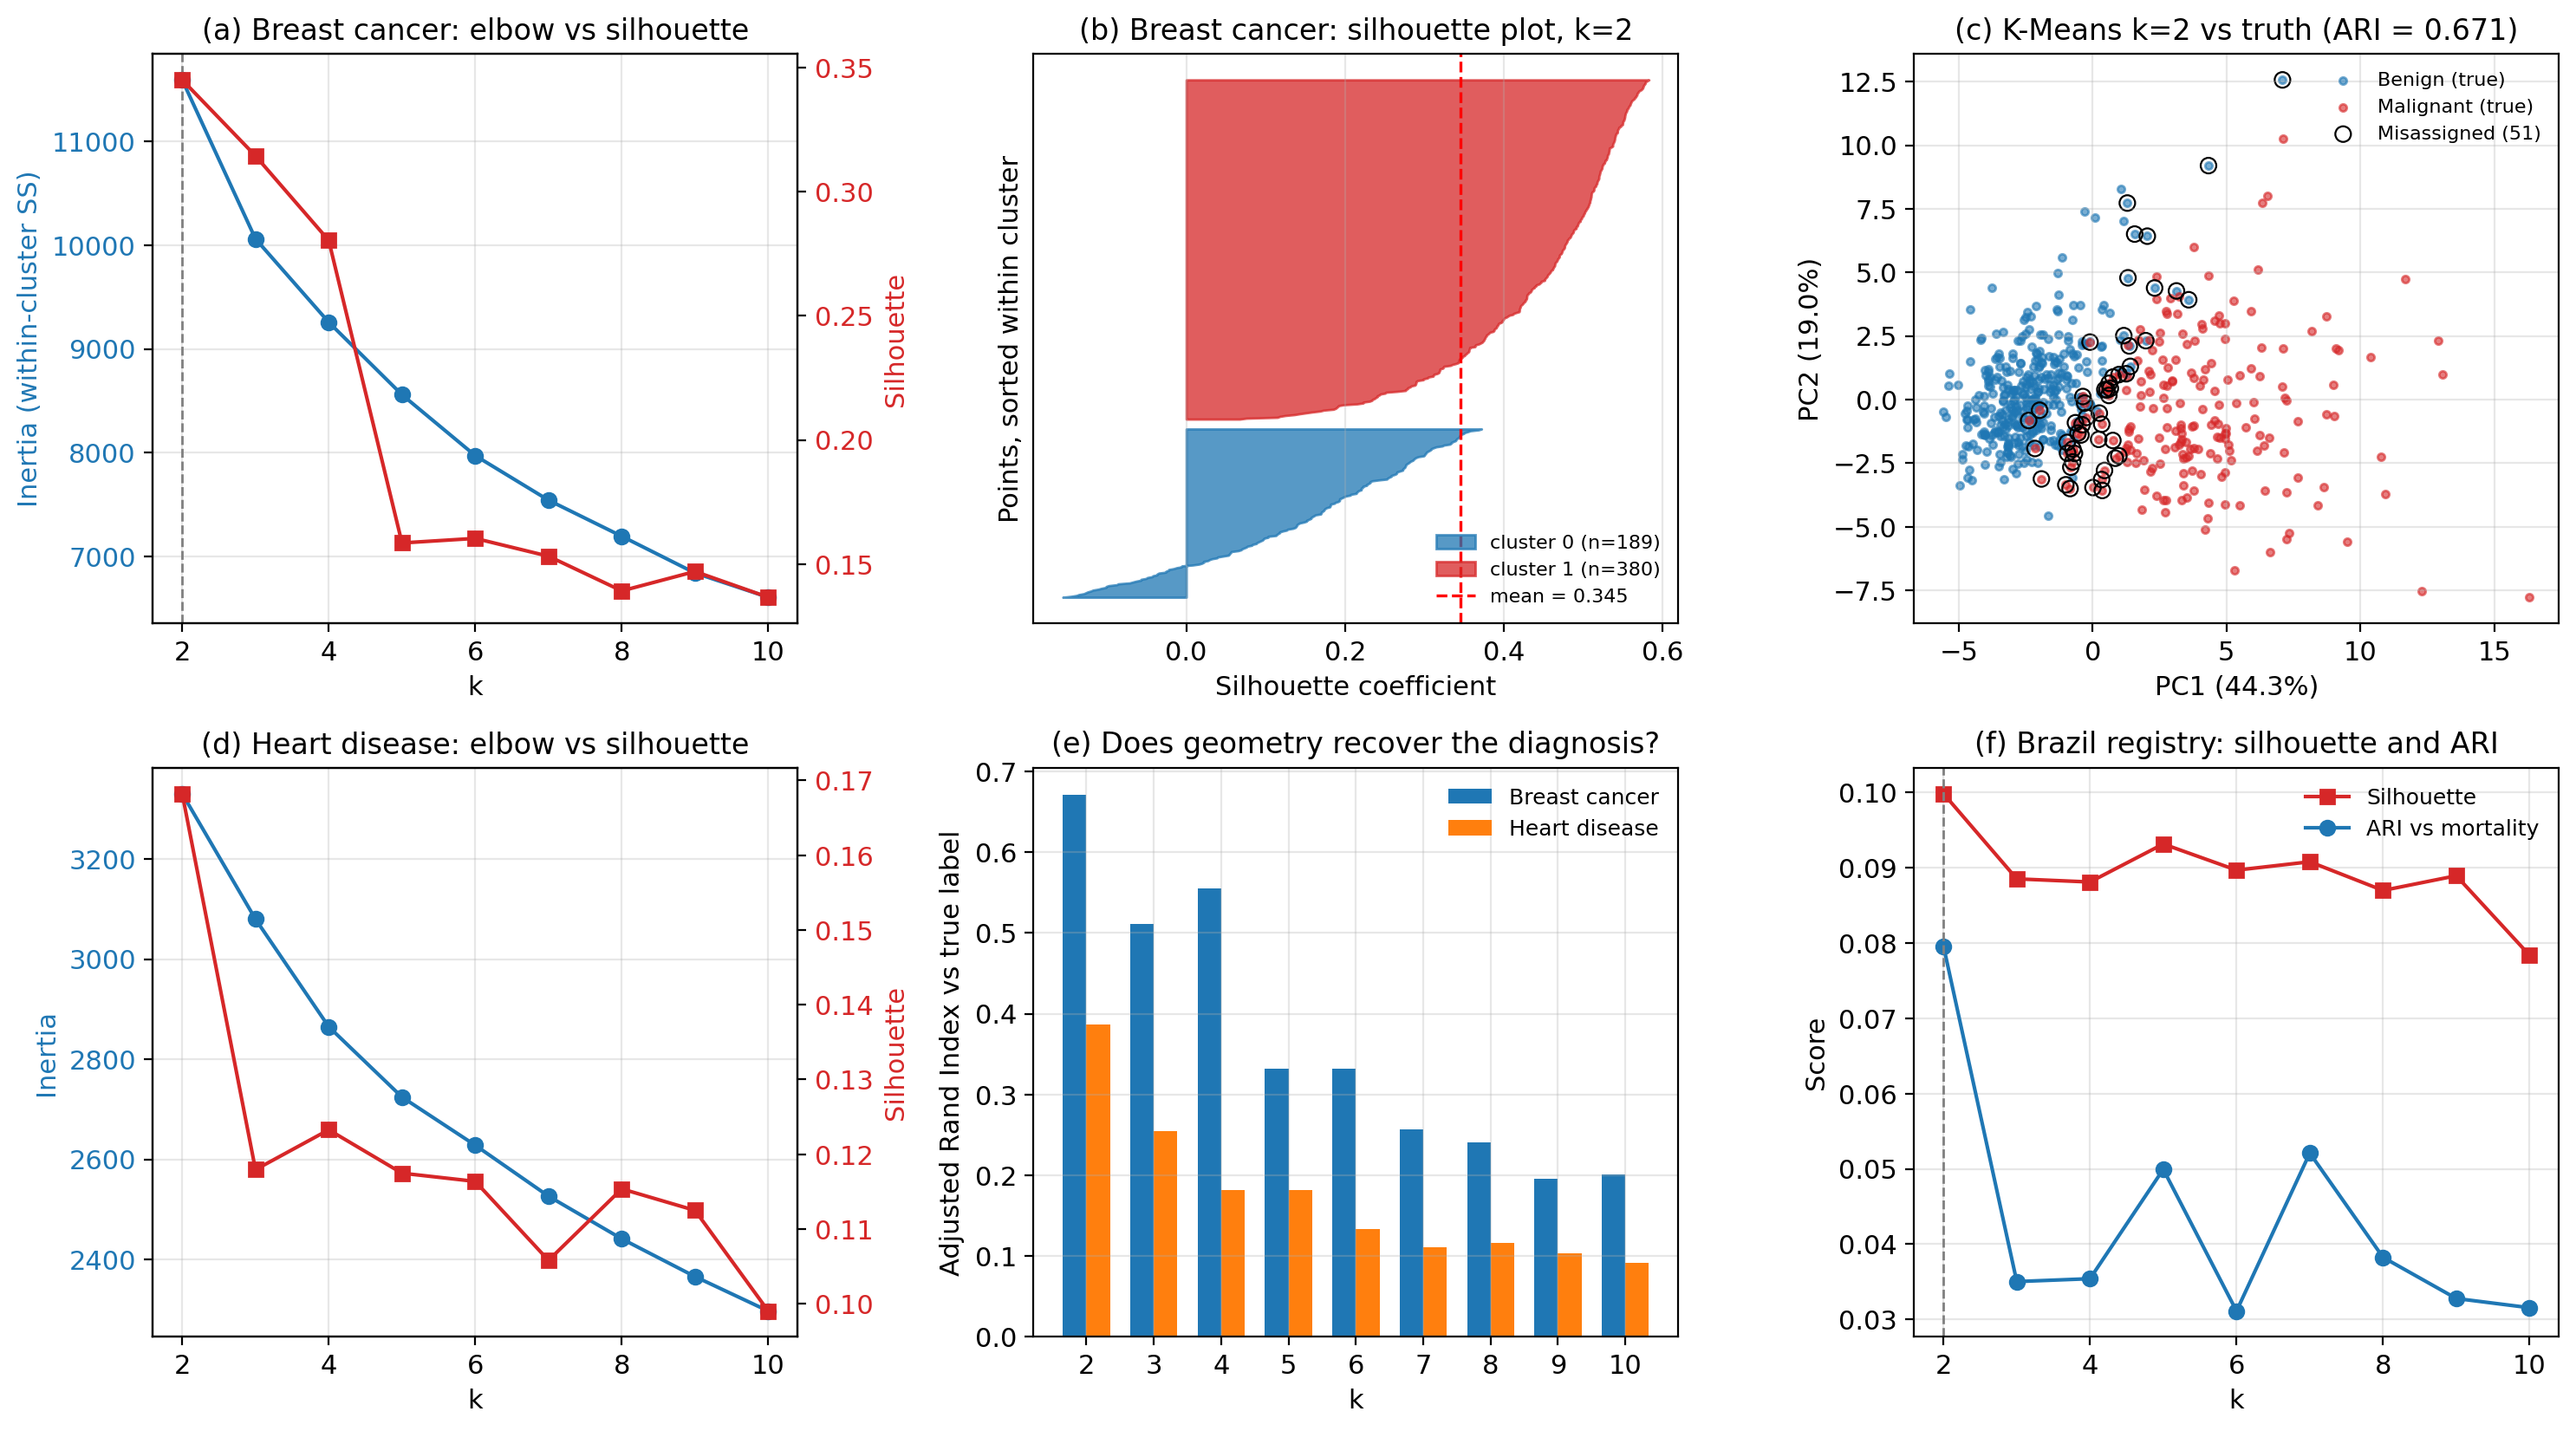

In [8]:
from IPython.display import Image
Image('../figures/fig_week10_kmeans.png')

## Week 10 conclusions

- Silhouette correctly identifies k=2 on breast cancer without labels.
- A higher silhouette does not mean a better clustering. The unscaled comparison is a
  concrete counterexample and the single most useful thing this week produced.
- Unsupervised geometry recovers the breast-cancer diagnosis at 91% agreement, which is
  independent corroboration of every supervised result across both milestones.
- K-Means is the wrong tool for one-hot encoded categorical data, and says so clearly
  through a silhouette of 0.10.